# Analisi preliminare referti annotati reali

# Preliminari

In [1]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

In [2]:
plt.style.use('ggplot')

# Load Data

In [3]:
# Get data

data_path = Path('../data/base.tumoreprimitivo.csv/')
# Se il file non è presente, inserirlo manualmente prendendolo dalla cartella dropbox

data = pd.read_csv(data_path)

In [4]:
display(data.head())
print(f'{data.shape = }')

,id,profile,discrepanze_rilevate,motivazioni_discrepanze,radiologist,patient_id,sesso,data_nascita,interpretazioni,report_text,...,coinvolgimento_fascia_mesorettale,distanza_minima_fascia_ore,linfonodi_sospetti,numero_linfonodi_non_conosciuto,sedi_locoregionali,sedi_non_locoregionali,depositi_tumorali,numero_depositi,emvi_esteso,status
0,306,GuidoImbemba,['nessuna'],nessuna,NaN,6167209,F,1951-01-16,NaN,IN CORRISPONDENZA DELLA PARETE LATERALE DESTRA...,...,NaN,NaN,3.0,False,['mesorettali'],[],NaN,0.0,no,complete
1,305,GuidoImbemba,['nessuna'],nessuna,NaN,32798134,M,1949-01-23,NaN,SI SEGNALA LA PRESENZA IN CORRISPONDENZA DEL R...,...,NaN,NaN,0.0,True,['rettali_superiori'],[],NaN,0.0,no,complete
2,304,GuidoImbemba,['nessuna'],nessuna,NaN,50847102,F,1960-05-25,NaN,"IN CORRISPONDENZA DEL RETTO MEDIO- BASSO , DA ...",...,NaN,NaN,0.0,True,"['mesorettali', 'rettali_superiori', 'otturato...",[],NaN,0.0,si,complete
3,303,GuidoImbemba,['nessuna'],nessuna,NaN,50113323,M,1948-06-25,< o > 5 mm?,SI RILEVA UN ISPESSIMENTO PARIETALE VEGETANTE ...,...,NaN,NaN,0.0,False,[],[],NaN,0.0,no,complete
4,302,GuidoImbemba,['nessuna'],nessuna,NaN,48531651,M,1955-08-13,< o > 5 mm?,"IN CORRISPONDENZA DEL RETTO MEDIO-ALTO , DA CI...",...,NaN,NaN,3.0,False,"['mesorettali', 'rettali_superiori']",[],NaN,0.0,no,complete


data.shape = (229, 45)


# Elimina righe doppie

In [5]:
# Intere righe duplicate. Keep last perchè i report hanno id decrescente
duplicati = data.iloc[:, 1:].duplicated(keep='last')
print(f'Numero righe duplicate: {duplicati.sum()}')

data_clean = data[duplicati == False]
print('Righe doppie eliminate')

# Rimuovi righe con report duplicati
duplicati = data_clean['report_text'].duplicated(keep='last')
print(f'Numero righe con stesso referto: {duplicati.sum()}')

data_clean = data_clean[duplicati == False]
print('Righe eliminate')

data_clean.reset_index(inplace=True, drop=True)

print(f'{data_clean.shape = }')

Numero righe duplicate: 0
Righe doppie eliminate
Numero righe con stesso referto: 9
Righe eliminate
data_clean.shape = (220, 45)


In [6]:
data_clean[data_clean.distanza_oai == 8.7]

,id,profile,discrepanze_rilevate,motivazioni_discrepanze,radiologist,patient_id,sesso,data_nascita,interpretazioni,report_text,...,coinvolgimento_fascia_mesorettale,distanza_minima_fascia_ore,linfonodi_sospetti,numero_linfonodi_non_conosciuto,sedi_locoregionali,sedi_non_locoregionali,depositi_tumorali,numero_depositi,emvi_esteso,status
211,56,PietroPaoloAzzaro,['nessuna'],nessuna,NaN,46738217,M,1956-09-08,NaN,RM ADDOME INFERIORE (S/C MDC)\r\nESAME ESEGUIT...,...,NaN,7.0,4.0,False,"['mesorettali', 'otturatori']",[],no,0.0,no,incomplete


# Analisi preliminari delle colonne

In [7]:
print(data_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 45 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      220 non-null    int64  
 1   profile                                 220 non-null    object 
 2   discrepanze_rilevate                    220 non-null    object 
 3   motivazioni_discrepanze                 220 non-null    object 
 4   radiologist                             2 non-null      object 
 5   patient_id                              220 non-null    int64  
 6   sesso                                   218 non-null    object 
 7   data_nascita                            219 non-null    object 
 8   interpretazioni                         83 non-null     object 
 9   report_text                             220 non-null    object 
 10  morfologia                              212 non-null    object

## Reports

In [8]:
# Stampa alcuni referti
if True:
    for r in data_clean['report_text'].head(2):
        print(r)
        print(f"\n{100*'-'}\n")

IN CORRISPONDENZA DELLA PARETE LATERALE DESTRA DEL RETTO BASSO, DA SUBITO AL DI SOPRA DELLO SFINTERE ANALE INTERNO CON ESTENSIONE CRANIALE PER CIRCA 3,5 CM , È PRESENTE FORMAZIONE AGGETTANTE CHE OCCUPA 2/4 DELLA CIRCONFERENZA DEL LUME , SI PRESENTA MORFOLOGICAMENTE A ""SCODELLA"" ED INVIA DIGITAZIONI POLIPOIDI NEL MESORETTO DI DESTRA .
NEL MESORETTO DI DESTRA SONO INOLTRE PRESENTI DUE LINFONODI DEL DIAMETRO RISPETTIVAMENTE DI CIRCA 7 ED 8 MM ED UNO DEL DIAMTERO DI CIRCA 3 MM A CONTORNI SFUMATI SOSPETTI PER LOCALIZZAZIONE DI MALATTIA.
CONCLUSIONI : STADIAZIONE RM T3N1M0

----------------------------------------------------------------------------------------------------

SI SEGNALA LA PRESENZA IN CORRISPONDENZA DEL RETTO BASSO , DALLA GIUNZIONE RETTOANALE CON ESTENSIONE CRANIALE PER CIRCA 6 CM , DI UNA FORMAZIONE MODERATAMENTE IPERINTENSA NELLE SEQUENZE T2 DIPENDENTI CHE INTERESSA CIRCONFERENZIALMENTE IL RETTO BASSO ED INVIA DIGITAZIONI NEL MESORETTO UNA DELLE QUALI RAGGIUNGE, A SINISTR

In [9]:
data_plot = data_clean.fillna('NaN')
data_plot = data_plot.drop(index=data_plot[data_plot['profile'] == 'IlariaNacci'].index)

## Colonne extra
Colonne non rilevanti per l'allenamento del modello

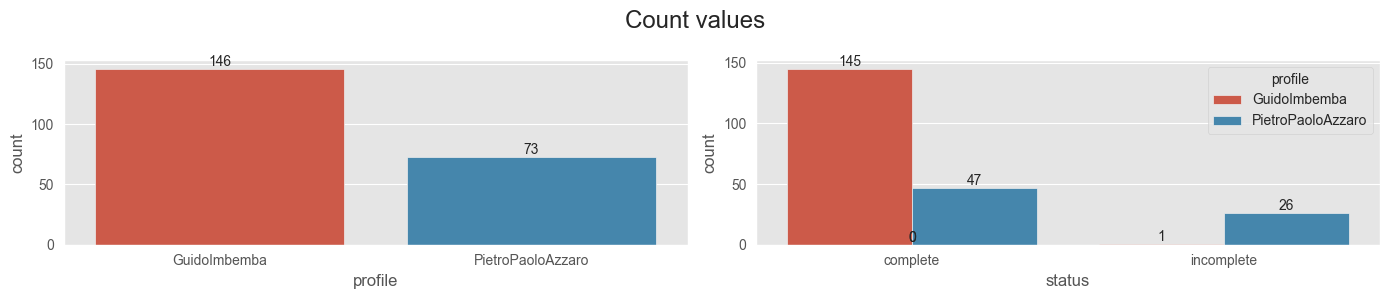

In [27]:
#columns_plot = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']
columns_plot = ['profile', 'status']
hue_column = 'profile'


n_columns = min(3, len(columns_plot))
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    if n_rows == 1:
        ax = axes[i]
    else:
        ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig("distribuzione_status_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

In [11]:
columns = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']
print(f'{len(columns) = }\n')
for col in columns:
    print(data_clean[col].value_counts().to_frame().T)
    print("\n")

len(columns) = 7

profile  GuidoImbemba  PietroPaoloAzzaro  IlariaNacci
count             146                 73            1


discrepanze_rilevate  ['nessuna']  ['n_classification', 'depositi_tumorali']
count                         218                                          2


motivazioni_discrepanze  nessuna
count                        220


radiologist  Arcioni Daniel  Barbaro
count                     1        1


sesso    M   F
count  129  89


motivazioni_extra  nessuna
count                  220


status  complete  incomplete
count        193          27




Eventualmente escludere righe con discrepanze

In [12]:
if False:
    display(data_clean[data_clean.discrepanze_rilevate == "['n_classification', 'depositi_tumorali']"].T)

## Colonne target non numeriche

In [13]:
print(data_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 45 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      220 non-null    int64  
 1   profile                                 220 non-null    object 
 2   discrepanze_rilevate                    220 non-null    object 
 3   motivazioni_discrepanze                 220 non-null    object 
 4   radiologist                             2 non-null      object 
 5   patient_id                              220 non-null    int64  
 6   sesso                                   218 non-null    object 
 7   data_nascita                            219 non-null    object 
 8   interpretazioni                         83 non-null     object 
 9   report_text                             220 non-null    object 
 10  morfologia                              212 non-null    object

In [14]:
columns = ['posizione', 'posizione_multiple',
       'lesioni_ossee',
       'infiltrazione_organi_dettagli',
       'sedi_locoregionali', 'sedi_non_locoregionali']

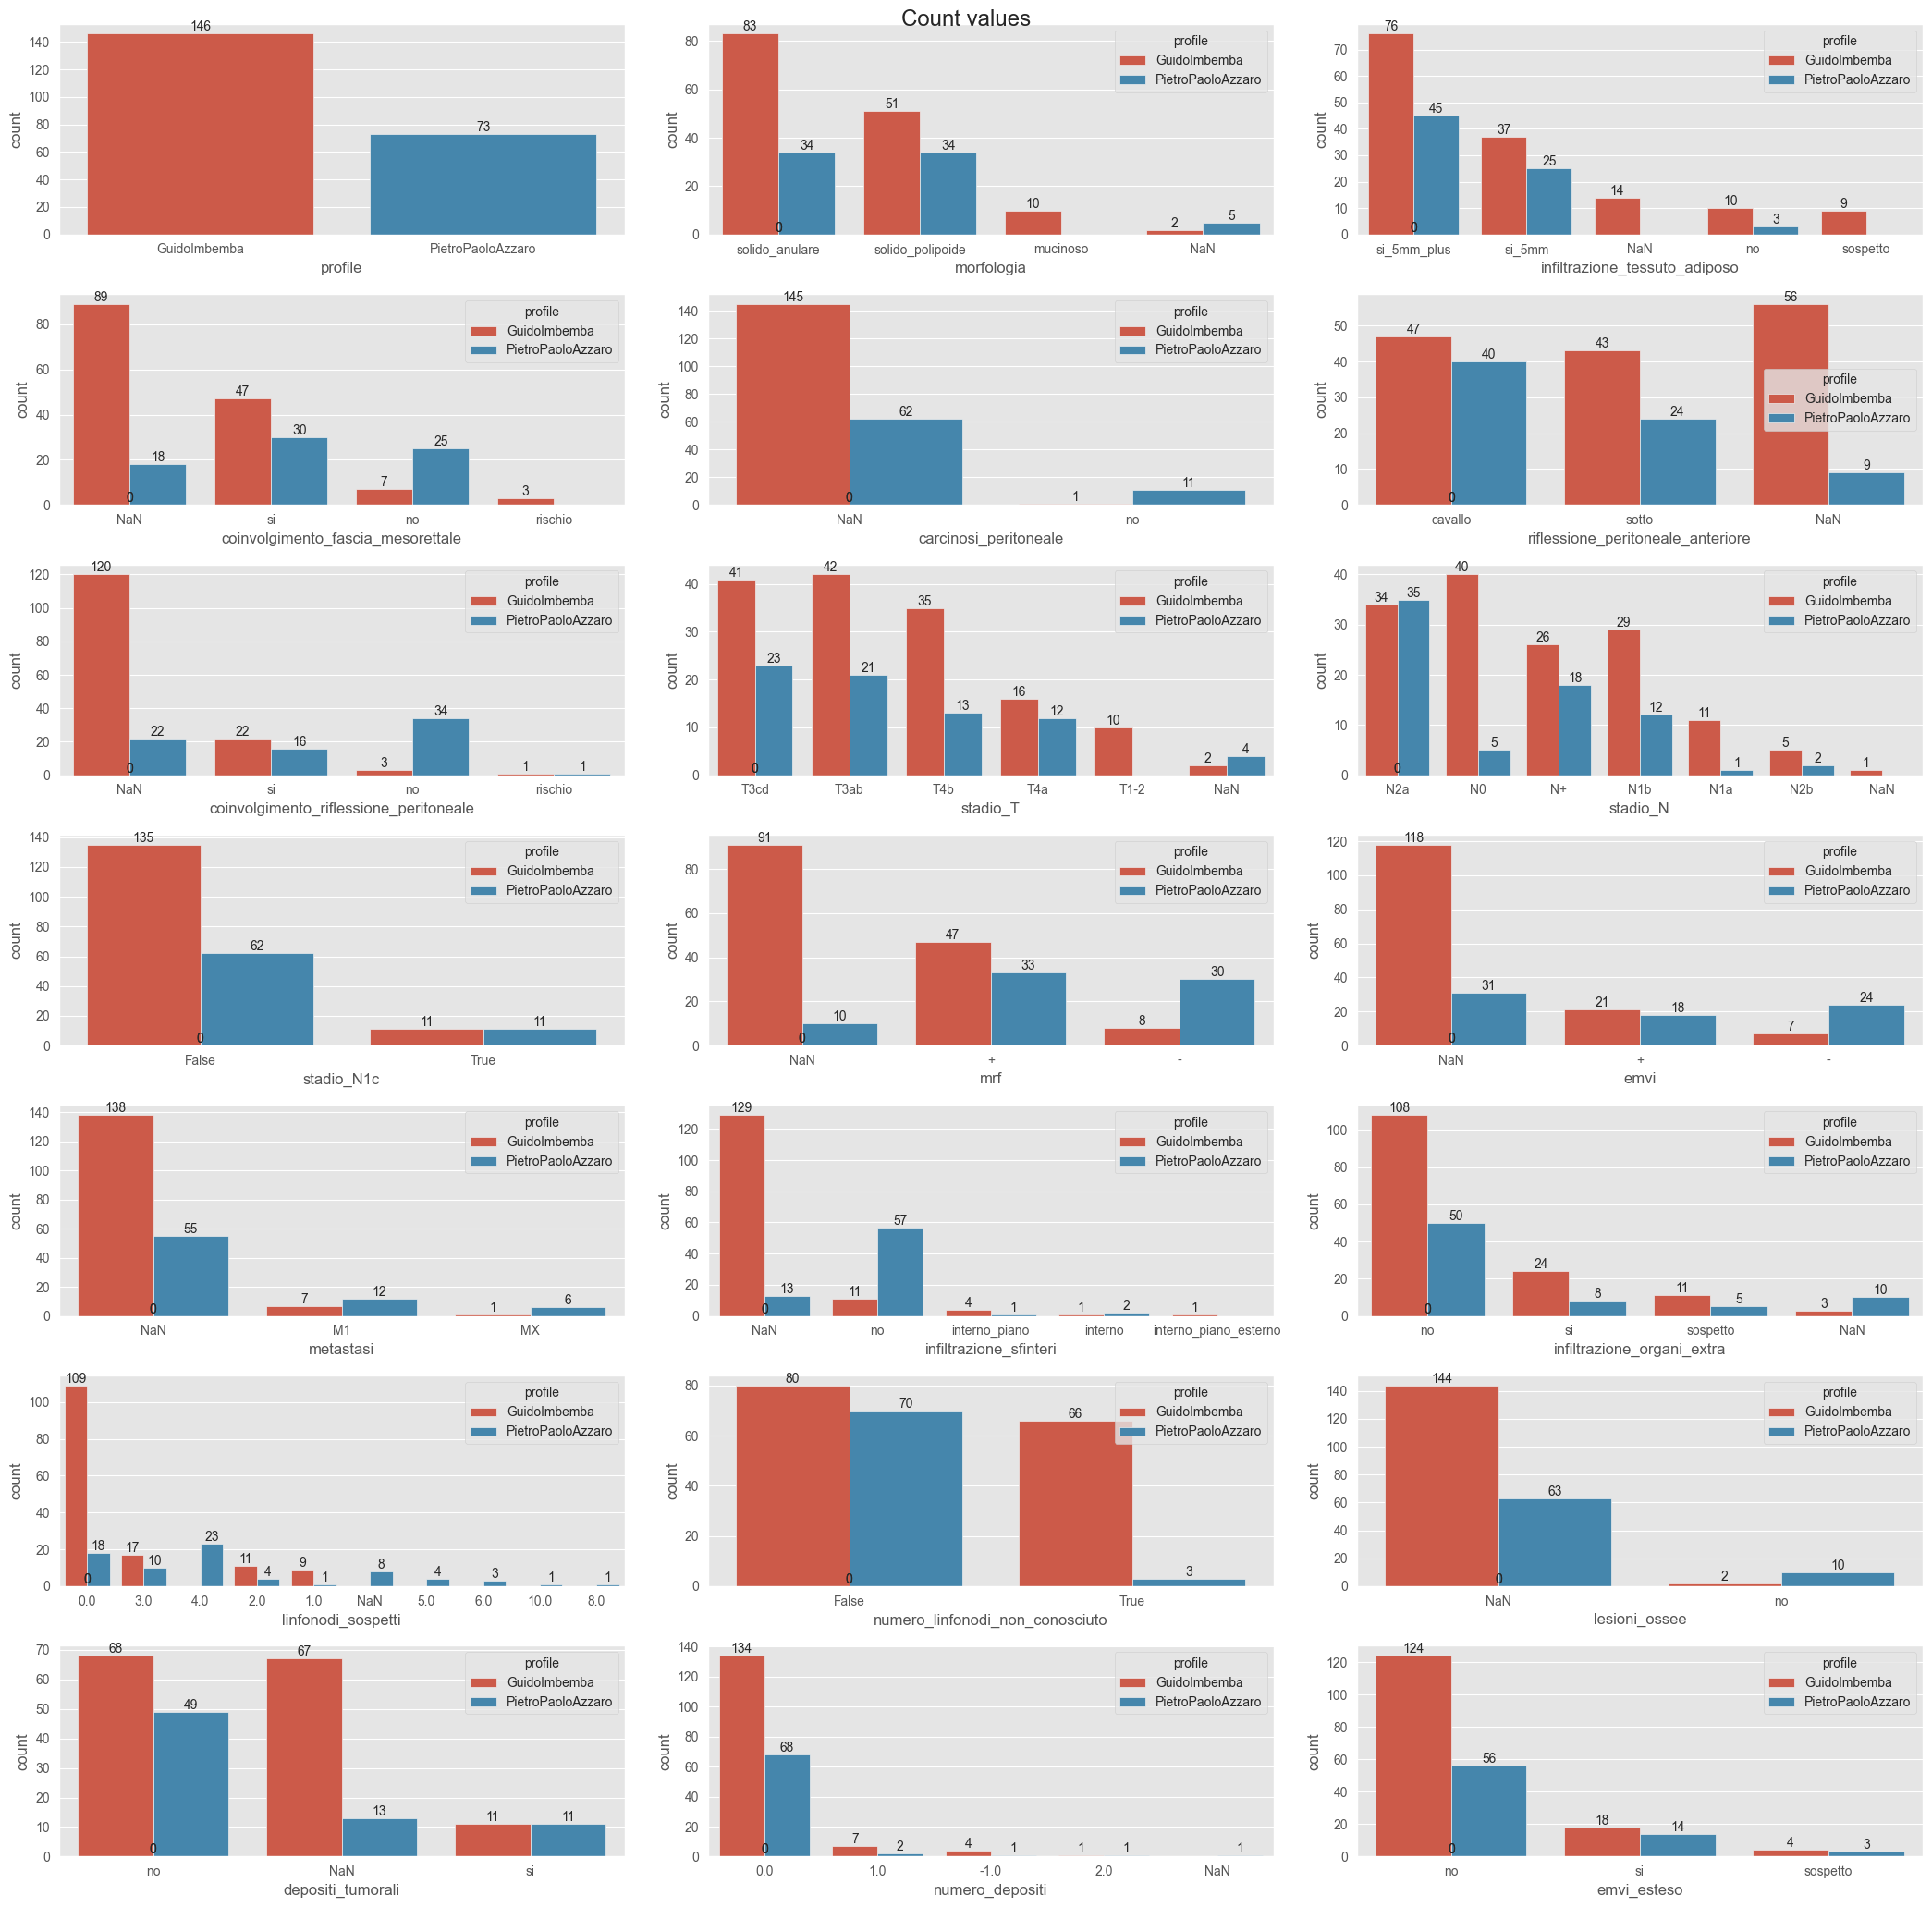

In [18]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

hue_column = 'profile'
columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

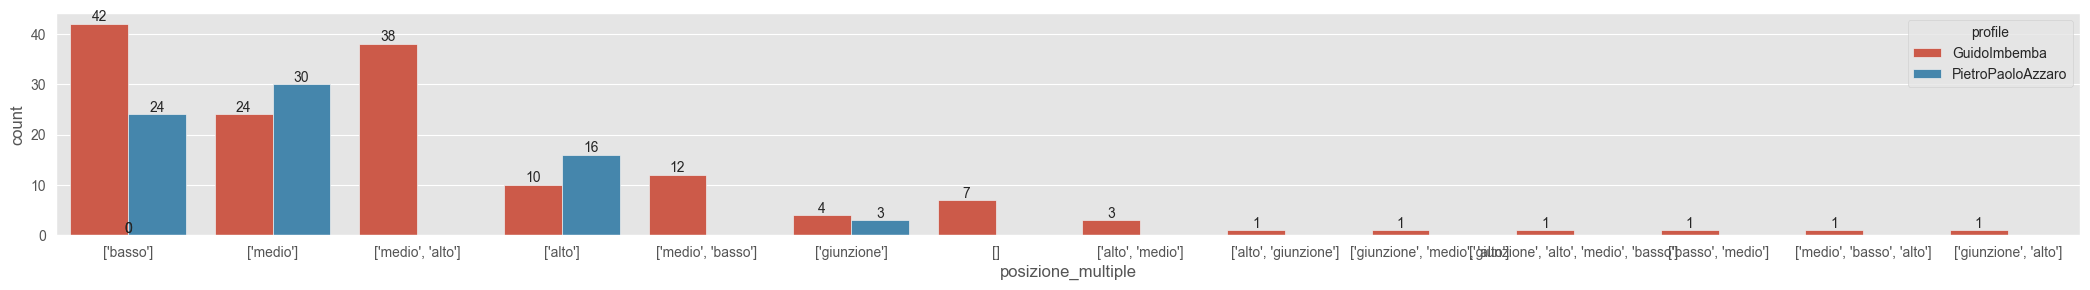

In [16]:
fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione_multiple', order=data_plot['posizione_multiple'].value_counts().index, ax=ax, hue='profile')
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [68]:
columns = ['posizione', 'posizione_multiple',
       'lesioni_ossee',
       
       
       'infiltrazione_organi_dettagli',
       
       
       'sedi_locoregionali', 'sedi_non_locoregionali']

print(f'{len(columns) = }\n')
for col in columns:
    print(data_clean.fillna('NaN')[col].value_counts().to_frame())
    print("\n")

len(columns) = 6

           count
posizione       
medio         84
NaN           50
basso         50
alto          28
giunzione      8


                                         count
posizione_multiple                            
['basso']                                   66
['medio']                                   54
['medio', 'alto']                           38
['alto']                                    26
['medio', 'basso']                          12
[]                                           8
['giunzione']                                7
['alto', 'medio']                            3
['alto', 'giunzione']                        1
['giunzione', 'medio', 'alto']               1
['giunzione', 'alto', 'medio', 'basso']      1
['basso', 'medio']                           1
['medio', 'basso', 'alto']                   1
['giunzione', 'alto']                        1


               count
lesioni_ossee       
NaN              207
no                12
si                 1




## Colonne target numeriche

In [11]:
colonne_target_numeriche = ['ore_inizio', 'ore_fine', 'dimensione_dll',
    'dimensione_dap', 'spessore_parietale', 'estensione_cranio_caudale',
    'distanza_oai', 'distanza_minima_fascia_ore',
    'linfonodi_sospetti', 'sedi_locoregionali', 'sedi_non_locoregionali',
    'depositi_tumorali', 'numero_depositi']

In [12]:
data_clean[colonne_target_numeriche].describe().T

,count,mean,std,min,25%,50%,75%,max
ore_inizio,76.0,9.250000,3.495235,1.0,6.00,12.0,12.00,12.0
ore_fine,76.0,9.710526,3.617792,1.0,6.75,12.0,12.00,12.0
dimensione_dll,14.0,41.642857,24.269662,15.0,24.00,38.0,47.25,105.0
dimensione_dap,11.0,48.090909,31.325563,21.0,30.00,38.0,50.50,120.0
spessore_parietale,44.0,19.681818,12.463477,7.0,12.00,16.5,22.00,60.0
estensione_cranio_caudale,210.0,49.257143,17.111528,18.0,37.25,48.5,57.75,130.0
distanza_oai,195.0,45.018974,28.086173,0.0,25.00,50.0,61.50,120.0
distanza_minima_fascia_ore,29.0,7.724138,3.624289,1.0,5.00,8.0,10.00,12.0
linfonodi_sospetti,212.0,1.297170,1.862931,0.0,0.00,0.0,3.00,10.0
numero_depositi,219.0,0.036530,0.315558,-1.0,0.00,0.0,0.00,2.0


escludere le segenti colonne perchè hanno troppi valori nulli:
- ore_inizio
- ore_fine
- dimensione_dll
- dimensione_dap
- distanza_minima_fascia_ore

## Colonne conclusioni

In [13]:
for col in ['stadio_T', 'stadio_N', 'stadio_N1c', 'mrf', 'emvi', 'metastasi']:
    print(data_clean.fillna('Nan')[col].value_counts())
    print("\n")

stadio_T
T3cd    64
T3ab    63
T4b     49
T4a     28
T1-2    10
Nan      6
Name: count, dtype: int64


stadio_N
N2a    69
N0     45
N+     44
N1b    41
N1a    12
N2b     7
Nan     1
N1c     1
Name: count, dtype: int64


stadio_N1c
False    198
True      22
Name: count, dtype: int64


mrf
Nan    101
+       81
-       38
Name: count, dtype: int64


emvi
Nan    149
+       39
-       32
Name: count, dtype: int64


metastasi
Nan    193
M1      20
MX       7
Name: count, dtype: int64


